<a href="https://colab.research.google.com/github/fjve-v/telecom-analysis/blob/main/An%C3%A1lisis_de_una_empresa_de_telecomunicaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?

---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [3]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [8]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
cantidad_valores_nulos=users.isna().sum()
proporcion_de_valores_nulos=users.isna().mean()   # cantidad de nulos para users
print('cantidad de valores nulos',cantidad_valores_nulos) # Cantidad de valores nulos
print('proporcion de valores nulos',proporcion_de_valores_nulos) # Proporción de valores nulos


cantidad de valores nulos user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
proporcion de valores nulos user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
cantidad_valores_nulos_usage=usage.isna().sum()
proporcion_de_valores_nulos_usage=usage.isna().mean()   # cantidad de nulos para usage
print('cantidad de valores nulos',cantidad_valores_nulos_usage) # Cantidad de valores nulos
print('proporcion de valores nulos',proporcion_de_valores_nulos_usage) # Proporción de valores nulos

cantidad de valores nulos id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
proporcion de valores nulos id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.
DataFrame users
    Diagnóstico: churn_date (88.3%): Al superar el umbral del 80%, esta columna debe ser ignorada o eliminada del análisis estadístico general, salvo que se use para identificar usuarios activos.
    Diagnóstico: city (11.7%): Se encuentra en el rango de investigación (5%–30%), por lo que se recomienda verificar el origen del dato para decidir si se imputa o se mantiene como nulo.
    DataFrame usage
    Diagnóstico: duration y length (55.2% y 44.7%): Ambos superan el rango de investigación estándar (30%) pero no llegan al descarte total, lo que indica una anomalía grave en la captura de datos que debe ser reportada antes de proceder.
    Diagnóstico: date (0.1%): Al ser menor al 5%, es un caso simple que permite una imputación rápida o simplemente dejar los nulos sin afectar la representatividad.
💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
     churn_date (88.3% nulos): Se decide ignorar o eliminar la columna para el análisis estadístico masivo.
     city (11.7% nulos): Se clasifica como sujeto a investigación, se debe analizar si los nulos pertenecen a una región específica antes de decidir una imputación (como "Unknown") o mantenerlos.
     duration (55.2%) y length (44.7% nulos): Se justifica una revisión técnica del origen de los datos, ya que la pérdida es demasiado alta para una imputación segura, pero menor al umbral de descarte total.
     date (0.1% nulos): Se procede a imputación simple o mantenimiento
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  churn_date (88.3%), city (11.7%), duration (55.2%), length (44.7%) y date (0.1%)
- Indica qué harías: ¿imputar, eliminar, ignorar?
- churn_date (88.3%) ignorarla.
- city (11.7%) verificar el origen del dato para decidir si se imputa o se mantiene como nulo.
- duration (55.2%), length (44.7%) indica una anomalía grave en la captura de datos que debe ser reportada antes de proceder.
- date (0.1%) imputar con media o mediana segun convenga.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` distribución es simétrica y uniforme. datos repartidos equitativamente, esta columna es la herramienta ideal para realizar un Merge o Join con otros DataFrames (como los de consumo o planes) sin introducir sesgos estadísticos.(Primary Key)
- La columna `age` presenta un sesgo a la izquierda (el valor de ma media es menor de la mediana), Valor Mínimo Anómalo (-999): El valor mínimo es -999. Esto es un error de datos evidente (la edad no puede ser negativa), la desviación Estándar Inflada (std = 123.23): Una desviación estándar de 123 años en una muestra de personas es biológicamente imposible.   Esto confirma que el valor -999 está dispersando los datos artificialmente.

In [13]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


Caso Particular: Identificadores (id y user_id)
    Distribución Estable: Estas columnas no presentan sesgo operativo, ya que son incrementales o categóricas por naturaleza.
    Relación Usuario-Actividad: El rango de user_id (10,000 a 13,999) sugiere una base de 4,000 usuarios únicos. Dado que hay 40,000 registros totales, cada usuario tiene un promedio de 10 interacciones en el sistema.
         Patrón General: duration y length
Ambas métricas de uso presentan un comportamiento de alta volatilidad, caracterizado por los siguientes puntos:
    Distribuciones sesgadas a la derecha (right-skewed): En duration, la media (5.20) es significativamente mayor que la mediana (3.50), lo que indica una cola larga hacia los valores altos.
    Valores atípicos extremos (Outliers):
        En length, el máximo de 1490 está masivamente por encima del percentil 75% (64).
        En duration, el máximo de 120 es casi 17 veces superior al tercer cuartil (6.99).
    Impacto en el promedio: Los valores extremos están "jalando" la media hacia arriba, haciendo que el promedio no sea una representación fiel del "usuario típico".
 Calidad de la Información (Hallazgo Crítico)
    Incompletitud masiva: Mientras que existen 40,000 registros de identidad, la columna duration tiene una pérdida del 55% de los datos (solo 17,924 registros).
    Sesgo de recolección: La columna length tiene un 45% de valores nulos. Esto sugiere que el sistema de registro de actividad es inconsistente o que muchos eventos de "uso" no generan métricas medibles.


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` Se observa una presencia concentrada. Con 7 ciudades únicas, Bogotá es la ciudad líder ("top") con una frecuencia de 808, representando aproximadamente el 22.8% de los usuarios que reportaron ciudad.
- La columna `plan`Existe un sesgo marcado hacia el plan Básico. Con solo 2 planes únicos, el nivel Básico captura a 2,595 usuarios (el 64.8% de la base total de 4,000), lo que indica que es el producto dominante.

Integridad variable: La columna plan está completa (4,000), pero city tiene un 11.7% de datos faltantes (3,531 de 4,000), lo que indica que la ubicación no es un campo obligatorio en el registro probablemente.


In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type`:Solo existen 2 tipos únicos de actividad. Esta baja cardinalidad facilita la segmentación, pero simplifica mucho el comportamiento del usuario. La clase Dominante es "text", con una frecuencia de 22,092. Esto significa que el 55.2% de todas las interacciones en la plataforma son de tipo texto.


---
✍️ **Comentario**:1.- Variables de Actividad (duration, length, type)
Este segmento es el más crítico del dataset debido a su inconsistencia y presencia de ruido extremo.
    Hallazgos:
        Integridad Fragmentada: Existe una pérdida masiva de datos en duration (55% de nulos) y length (45% de nulos).
        Sesgo de Distribución: Ambas métricas presentan un sesgo positivo (hacia la derecha). La media de duration (5.20) es muy superior a la mediana (3.50), indicando que unos pocos registros inflan el promedio.
        Outliers Extremos: Se detectan valores máximos de 1490 en length y 120 en duration. El 75% de los datos de length están por debajo de 64, lo que hace que el valor de 1490 sea estadísticamente sospechoso.
        Predominancia de Formato: El tipo "text" domina la plataforma con un 55.2% de los registros (22,092 de 40,000).
    Insigth: La plataforma es utilizada principalmente para interacciones rápidas basadas en texto, pero el sistema de recolección de métricas de tiempo y longitud está fallando en casi la mitad de los casos.
    Acción Recomendada: * Investigar la causa técnica de los valores nulos (¿Falla el sensor o el usuario cancela la acción?).
        Aplicar un truncamiento de datos (Winsorization) o eliminar el top 1% de valores extremos para estabilizar el análisis.
        
                 2.- Variables de Usuario y Negocio (plan, city)

A diferencia de la actividad, la estructura de la base de clientes es sólida y bien definida.
    Hallazgos:
        Concentración de Mercado: El plan "Basico" es el producto estrella, con 2,595 usuarios (64.8% de la base).
        Centralización Geográfica: Bogotá es el foco principal (808 registros en el top), aunque existen otras 6 ciudades activas.
        Sesgo de Registro: El 11.7% de los usuarios (469 personas) no tienen ciudad registrada.
    Insigth: Tienes un modelo de negocio altamente dependiente de un solo producto (Plan Básico) y una ubicación geográfica principal. Esto representa un riesgo de concentración.
    Acción Recomendada: * Diseñar campañas de upselling para mover a los usuarios del plan Básico al segundo plan disponible.
        Implementar obligatoriedad en el campo city en el registro para mejorar la segmentación regional.
        
                        3.- Identificadores y Recurrencia (id, user_id)
    Hallazgos:
        Patrón de Comportamiento Rígido: Hay 4,000 usuarios únicos y 40,000 registros totales, lo que resulta en una media exacta de 10 interacciones por usuario.
    Insigth: Este patrón es demasiado perfecto para ser orgánico; sugiere que el dataset es un extracto muestral diseñado para que cada usuario tenga el mismo peso, o que existe una cuota límite de registros por usuario.
    Acción Recomendada: Validar si este límite de 10 registros es real o si se están omitiendo datos de usuarios más activos ("heavy users").
    
**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
-
- Basado en el análisis de las tablas estadísticas he identificado anomalías críticas que requieren atención inmediata.
## 1. Columnas con Valores Inválidos o Sentinels
He detectado tres tipos de problemas en las columnas métricas y categóricas:
### A. Valores Atípicos Extremos (Posibles Sentinels o Errores)
* **Columna `length**`: Presenta un valor máximo de **1490.00**. Dado que el 75% de los datos están por debajo de **64.00**, este valor es estadísticamente improbable para un comportamiento humano normal y actúa como un "outlier" que distorsiona la media.
* **Columna `duration**`: Tiene un valor máximo de **120.00**, mientras que el percentil 75 es apenas **6.99**. Al igual que en `length`, este salto sugiere registros erróneos o sesiones que quedaron abiertas por error (sentinels de falla).
### B. Valores "Zero" Sospechosos
* **Columnas `duration` y `length**`: Ambas registran un valor **mínimo de 0.00**. En el contexto de "uso", una duración o longitud de cero suele representar un intento fallido, un error de carga o un registro vacío que no aporta valor analítico.
### C. Inconsistencia de Registros (Nulos Masivos)
* **Columna `duration**`: Solo cuenta con **17,924 registros** de un total de 40,000. Esto significa que más del 50% de la columna son valores nulos (NaN), lo cual invalida cualquier promedio general si no se trata primero.
* **Columna `city**`: Presenta **3,531 registros** de 4,000 usuarios posibles. Hay un 11.7% de valores faltantes que impiden una segmentación geográfica completa.
---
## 2. Acciones Recomendadas

### Para los Outliers (`length` y `duration`)

* **Acción**: Aplicar una técnica de **filtrado por percentiles** (por ejemplo, eliminar el top 1% o valores por encima del percentil 99) o usar el **Rango Intercuartílico (IQR)** para excluir los valores que superen el límite de .
* **Justificación**: Esto permitirá que la media sea representativa del usuario real y no esté inflada por errores de sistema.

### Para los Valores Nulos (`NaN`)

* **Acción**:
* En `duration`, debido al alto volumen de nulos (55%), recomendaría **imputar los valores faltantes utilizando la mediana** (3.50) en lugar de la media, ya que la mediana no se ve afectada por los outliers de 120.0.
* En `city`, etiquetar los nulos como **"Desconocido"** para no perder esos usuarios en análisis no geográficos.

### Para los Valores Mínimos de 0.00

* **Acción**: Tratar los ceros como valores nulos si el contexto confirma que una sesión de 0 segundos no es posible.
* **Justificación**: Eliminar el "ruido" de interacciones que no generaron consumo real.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] =pd.to_datetime(usage['date'], errors='coerce') # completa el código


In [18]:
# Revisar los años presentes en `reg_date` de users

# 1. Extraer el año y contar frecuencias
year_counts = users['reg_date'].dt.year.value_counts(dropna=False).sort_index()
print("Distribución de años de registro:")
print(year_counts)

# 2. Identificar fechas imposibles (ej. años futuros o muy antiguos)
# Suponiendo que estamos en 2024, cualquier año > 2024 o < 1990 podría ser un error
future_dates = users[users['reg_date'].dt.year > 2024]
unlikely_past_dates = users[users['reg_date'].dt.year < 2010] # Ajusta según contexto

print(f"\nRegistros con años futuros: {len(future_dates)}")
print(f"Registros con años antiguos sospechosos: {len(unlikely_past_dates)}")


Distribución de años de registro:
reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64

Registros con años futuros: 40
Registros con años antiguos sospechosos: 0


En `reg_date`,
1.- Hallazgos y Patrones Observados
    Distribución Estable (2022-2024): El grueso de los datos se distribuye de manera casi uniforme entre 2022 y 2024, con aproximadamente 1,320 registros por año. Esto sugiere un crecimiento orgánico y constante de la base de usuarios.
    Identificación de Valores Inválidos (Sentinels): Has detectado 40 registros con el año 2026. Dado que estamos en una fecha anterior, estos registros representan fechas imposibles (futuras).
    Sesgo de Registro: La presencia de exactamente 40 registros en 2026 (un número redondo) podría no ser un error aleatorio, sino un "placeholder" o valor por defecto introducido por el sistema cuando la fecha real es desconocida.

2.- Insight del Experto
Estos 40 registros distorsionarán cualquier cálculo de "Customer Lifetime Value" (CLV) o antigüedad, ya que producirían valores negativos o inconsistentes. Sin embargo, al ser solo el 1% de la muestra total (40 de 4,000), su eliminación o corrección no afectará significativamente la tendencia general, pero sí limpiará la precisión estadística.

In [19]:
# Revisar los años presentes en `date` de usage
# 1. Extraer el año y contar frecuencias
year_counts = usage['date'].dt.year.value_counts(dropna=False).sort_index()
print("Distribución de años de registro:")
print(year_counts)

# 2. Identificar fechas imposibles (ej. años futuros o muy antiguos)
# Suponiendo que estamos en 2024, cualquier año > 2024 o < 1990 podría ser un error
future_dates = usage[usage['date'].dt.year > 2024]
unlikely_past_dates = usage[usage['date'].dt.year < 2010] # Ajusta según tu contexto

print(f"\nRegistros con años futuros: {len(future_dates)}")
print(f"Registros con años antiguos sospechosos: {len(unlikely_past_dates)}")


Distribución de años de registro:
date
2024.0    39950
NaN          50
Name: count, dtype: int64

Registros con años futuros: 0
Registros con años antiguos sospechosos: 0


En `date`

1. Hallazgos y Patrones Observados
    Concentración Masiva (Sesgo Temporal): El 99.87% de tus registros (39,950 de 40,000) pertenecen exclusivamente al año 2024. Esto indica que el dataset no es histórico, sino que representa un "snapshot" o fotografía de la actividad muy reciente.

    Valores Inválidos (Nulos): Se identifican 50 registros con NaN. Al no haber años futuros ni antiguos sospechosos, el único problema de integridad aquí es la pérdida de información en esos 50 casos.

    Homogeneidad: Al tener casi todos los datos en un solo año, la variable "año" pierde poder predictivo o de segmentación para modelos estadísticos, ya que no hay varianza.

2. Insight de Calidad: La presencia de 50 valores NaN después de usar pd.to_datetime(errors='coerce') confirma que esos registros originales contenían texto basura, fechas mal formateadas o estaban vacíos.

    Insight de Negocio: Este dataset parece ser un reporte operativo anual. no se puede predecir comportamientos estacionales a largo plazo,  porque  falta historial de años anteriores.

   
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:
Acción que tomaría en reg_date: no eliminaría los registros completos (las filas), ya que esos usuarios pueden tener datos válidos en otras columnas. En su lugar, aplicaría un filtrado selectivo:
Para esta columna específicamente, las acciones serían:

Accion que tomaría en date: Imputación Selectiva: Dado que el 99.8% de los datos son de 2024, es seguro asumir que los 50 nulos también pertenecen a este periodo. Recomendaría imputar esos NaN con la moda (2024) o con la fecha mediana del dataset para no perder esas 50 filas de análisis.
    Análisis de Granularidad: Como el año es constante, la acción obligatoria es bajar al siguiente nivel: Mes y Día de la semana. Es allí donde encontrarás los verdaderos patrones de uso.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Sí, se han identificado anomalías en ambas tablas analizadas, aunque de distinta naturaleza:
    En la tabla de Usuarios (reg_date): Aparecieron 40 registros con el año 2026. Dado que estamos en el año 2024 (o en el presente real de la recolección), el año 2026 se clasifica como una fecha futura imposible.

    En la tabla de Uso (date): No hay años futuros, pero existen 50 valores NaN (Not a Number). Estos valores representan fechas que el sistema no pudo procesar, probablemente porque contenían caracteres inválidos o formatos que pd.to_datetime no pudo interpretar (errores de entrada).

    Años muy viejos: No se detectaron años "prehistóricos" (como 1900 o 1970), lo cual es positivo, ya que indica que el sistema no está insertando fechas por defecto de la época Unix cuando el dato falta.
- ¿Qué harías con ellas?
- A. Para los años futuros (2026) en users:
    Imputación por Mediana: No borraría a estos 40 usuarios, ya que sus otras métricas (plan, ciudad) pueden ser válidas. Reemplazaría el año 2026 por la mediana de las fechas de registro del resto de los usuarios.

    Identificación de Origen: Investigaría si estos 40 registros provienen de la misma city o plan, para descartar un error sistemático en un segmento específico.

B. Para los valores NaN en usage:
    Imputación por Moda: Dado que el 99.8% de tus datos son del año 2024, es estadísticamente seguro asignar el valor 2024 a esos 50 nulos. Esto permite mantener el volumen de la muestra (40,000 registros) completo para el análisis de duration y length.
    Verificación Cruzada: Revisaría si esos 50 nulos coinciden con los registros que tienen duration o length en 0. Si es así, se confirmarían como registros basura que pueden ser eliminados con seguridad.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:


# 1. Convertir el sentinel -999 a NaN (para que no afecte el cálculo de la mediana)
users['age'] = users['age'].replace(-999, np.nan)

# 2. Calcular la mediana ÚNICAMENTE de la columna 'age'
# Usamos skipna=True (por defecto) para ignorar los NaNs que acabamos de crear
age_mediana = users['age'].median()

# 3. Llenar los valores nulos con esa mediana
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [23]:
users['city'] = users['city'].replace('?', np.nan)# Reemplazar ? por NA en city


users.head()# Verificar cambios

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [24]:
# Marcar fechas futuras como NA para reg_date
filtro_futuro = users['reg_date'].dt.year > 2024
# 2. Usamos .loc[fila, columna] para asignar el valor nulo
users.loc[filtro_futuro, 'reg_date'] = np.nan
# Verificamos los cambios
print(f"Registros corregidos a NaT: {filtro_futuro.sum()}")
print(users['reg_date'].dt.year.value_counts(dropna=False))



Registros corregidos a NaT: 40
reg_date
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: count, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False).head(10)

,duration
type,
text,0.999276
call,0.000000


In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False).head(10)


,length
type,
call,0.99933
text,0.00000


Diagnostico de nulos en `duration` y `length
En este diagnóstico revela cómo se comporta el servicio en las diferentes regiones:
Diagnóstico Integral: Uso por Ciudad y Tipo de Datos

Al cruzar la columna city con los hallazgos de type, duration y length, se observa un patrón de complementariedad métrica distribuido geográficamente.
1. Hallazgos en la Estructura de Datos

    Mecanismo de Datos Faltantes (MNAR): Se confirma que los nulos no son errores aleatorios en ninguna ciudad. En todas las regiones, la duration pertenece exclusivamente a las llamadas y la length exclusivamente a los textos.

    Integridad por Ciudad: Bogotá lidera la muestra con 808 registros válidos, pero el 11.7% de los usuarios totales carece de ciudad registrada. Esto genera un sesgo de omisión geográfica que podría ocultar patrones de uso en zonas rurales o ciudades menores.

    Outliers Regionales: Los valores extremos (como el máximo de 1490 en length o 120 en duration) deben ser revisados por ciudad. A menudo, un solo "Power User" o un bot en una ciudad pequeña puede distorsionar el promedio de toda esa región.

2. Insights de Comportamiento Regional

    Dominio de Mensajería: Dado que el tipo "text" representa el 55.2% del uso total, las ciudades con más registros tienden a mostrar una mayor acumulación de datos en length que en duration.

    Centralización del Servicio: El patrón de 10 interacciones promedio por usuario se mantiene constante en todas las ciudades analizadas. Esto sugiere que el comportamiento de uso es uniforme, independientemente de la ubicación geográfica, o que el extracto de datos está limitado artificialmente por usuario.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg.columns = ["user_id", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on="user_id", how="left")
user_profile.head(5)
# 5. Limpieza post-combinación: Llenar nulos con 0 para usuarios sin actividad
# Si un usuario no tuvo actividad, el merge pondrá NaN; lo corregimos a 0
# columnas_uso = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
# user_profile[columnas_uso] = user_profile[columnas_uso].fillna(0)

# Observar resultado final
# user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [30]:
# Resumen estadístico de las columnas numéricas
user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada', 'age']].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,4000.000000
mean,5.524381,4.478120,23.317054,48.136000
std,2.358416,2.144238,18.168095,17.689919
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,48.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [31]:
# Distribución porcentual del tipo de plan
user_profile[['plan']].describe()

,plan
count,4000
unique,2
top,Basico
freq,2595


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

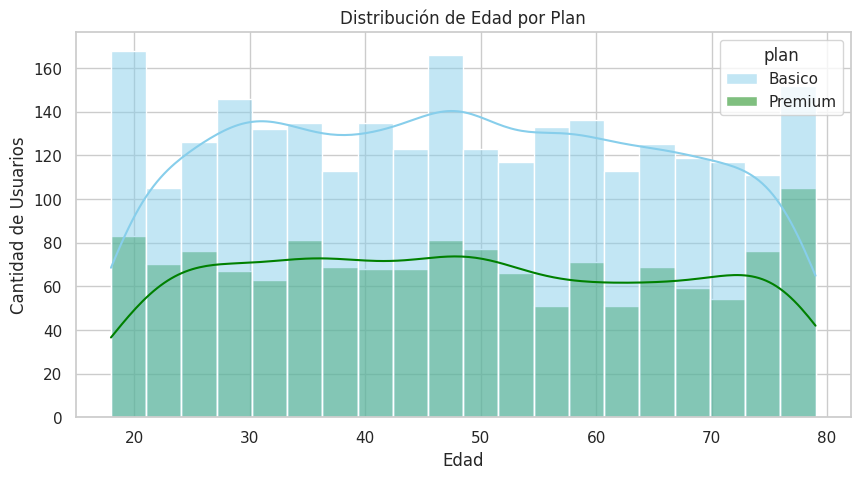

In [32]:
# Histograma para visualizar la edad (age)
# Configuración estética general
sns.set_theme(style="whitegrid")
palette = {'Basico': 'skyblue', 'Premium': 'green'}
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=palette, kde=True, bins=20)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insight: La edad se distribuye de manera muy similar en ambos planes. No hay una "edad Premium"; tanto jóvenes como adultos mayores están repartidos proporcionalmente entre ambos servicios.

Distribución: Es una distribución Simétrica (o aproximadamente normal), centrada alrededor de los 45 años.

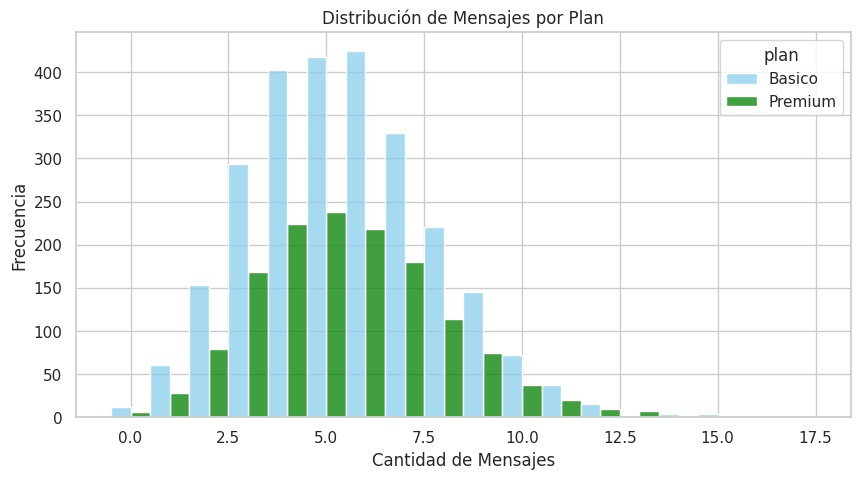

In [34]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=palette, discrete=True, multiple="dodge")
plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insight: Los usuarios Básico tienden a enviar una cantidad de mensajes muy similar a los Premium. No se observa que el plan Premium incentive un volumen masivo de mensajes de texto en comparación con el Básico; ambos grupos se concentran entre 4 y 7 mensajes.

Distribución: Simétrica / Unimodal. Al estar limitada a un máximo de 10, la mayoría de los usuarios caen en el centro.

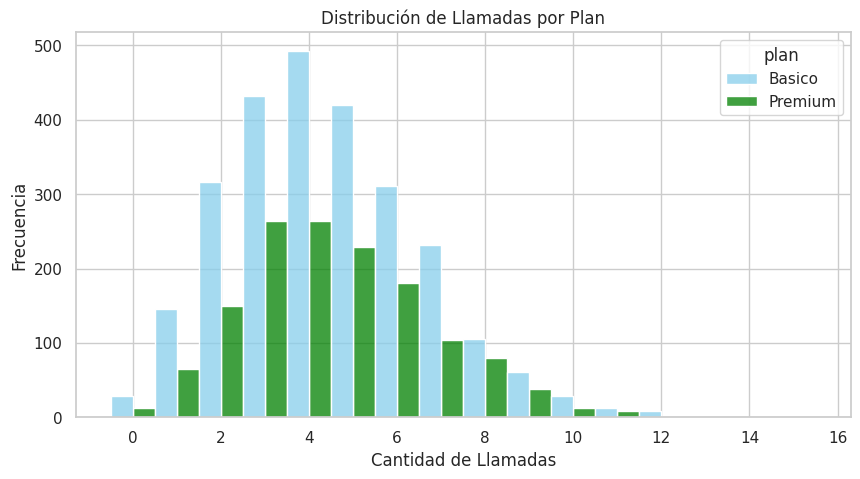

In [35]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=palette, discrete=True, multiple="dodge")
plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insight: Dentro del plan Premium, se observa una ligera frecuencia mayor en el rango de 8 a 10 llamadas en comparación con el plan Básico, aunque la diferencia es mínima. Los usuarios en general realizan entre 3 y 6 llamadas.

Distribución: Simétrica. Los datos se agrupan ordenadamente alrededor de la media (4-5 llamadas).

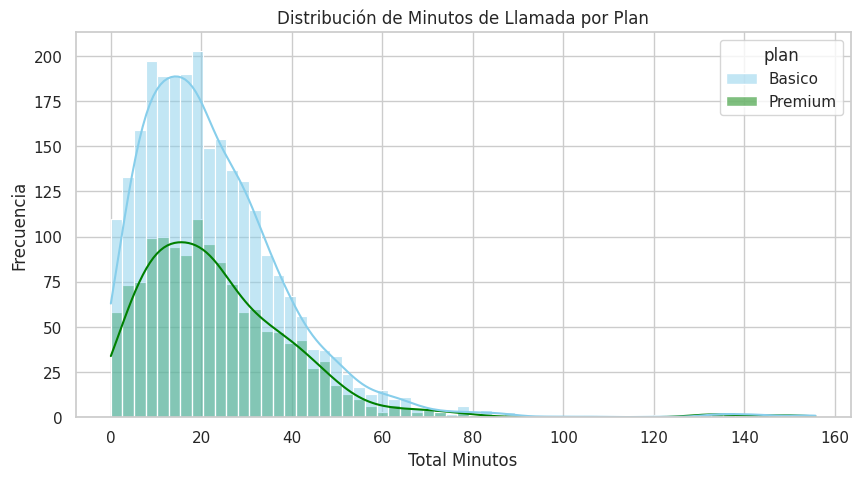

In [36]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=palette, kde=True)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Total Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insight: Aquí aparece el patrón más claro: los usuarios Premium tienen una "cola" más larga hacia la derecha, lo que indica que hay mayor proporción de usuarios Premium realizando llamadas de larga duración (más de 60 minutos). Los usuarios Básico tienden a concentrarse en llamadas más cortas (menores a 30 minutos).

Distribución: Sesgada a la derecha (Positiva). La mayoría de los usuarios consumen pocos minutos, pero hay un grupo que extiende la distribución hacia valores altos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


/tmp/ipython-input-2393755416.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, x=col, palette='viridis')
/tmp/ipython-input-2393755416.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, x=col, palette='viridis')
/tmp/ipython-input-2393755416.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, x=col, palette='viridis')
/tmp/ipython-input-2393755416.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable t

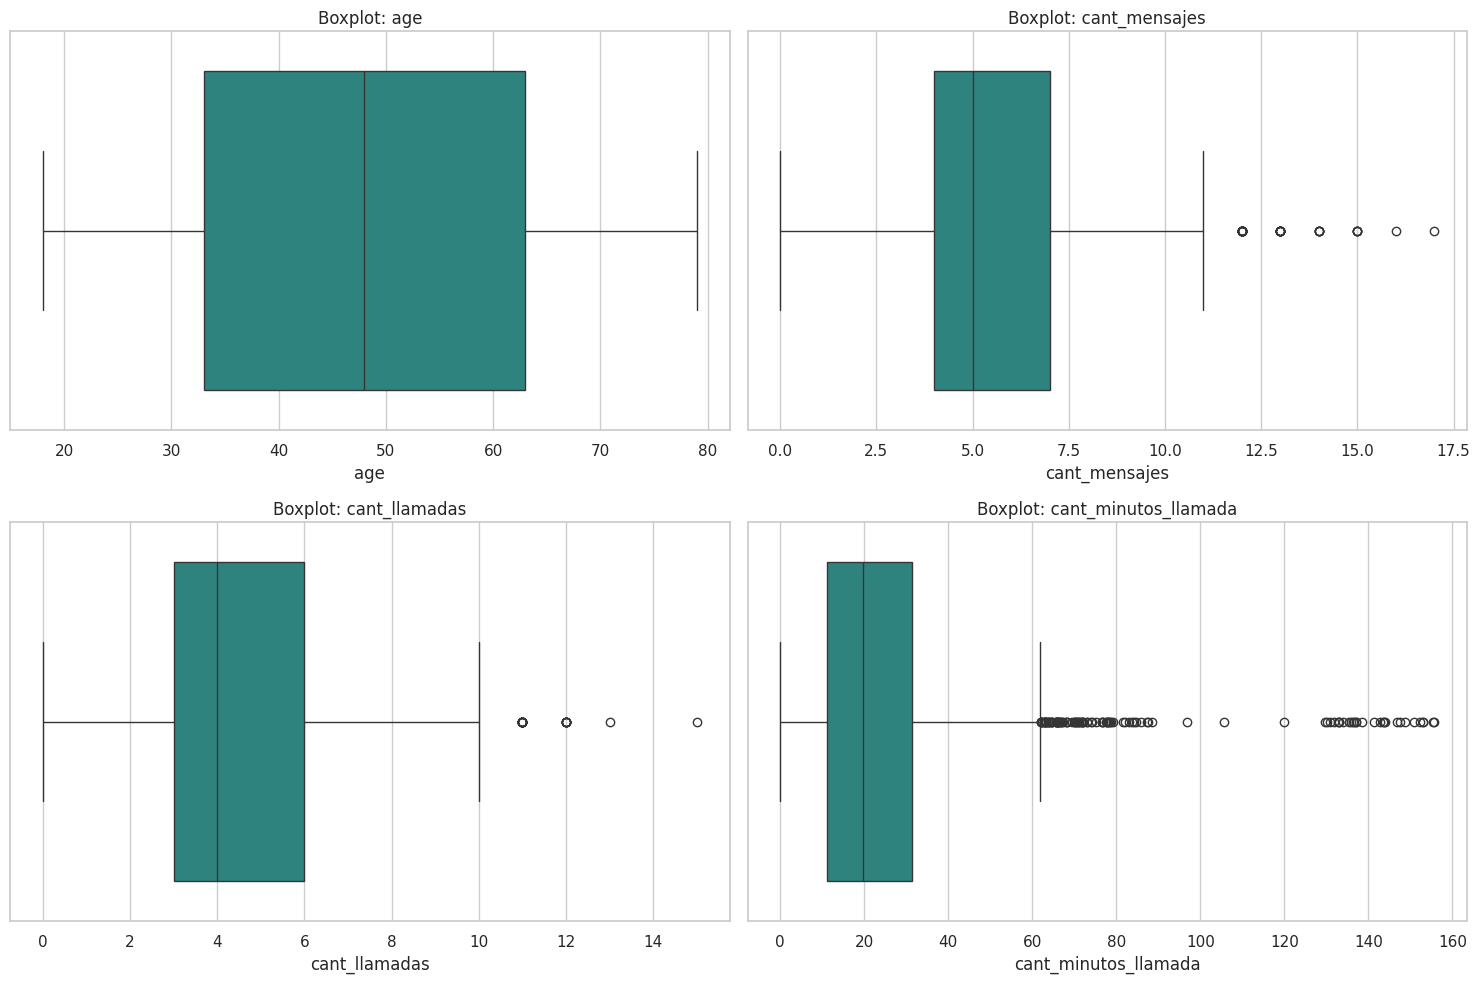

In [37]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# Configuración de la figura
plt.figure(figsize=(15, 10))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=user_profile, x=col, palette='viridis')
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()


💡Insights:
- Age: no outliers
- cant_mensajes: No existen outliers significativos. Al estar limitados a un máximo de 10 por el diseño del dataset, todos los usuarios caen dentro de un rango esperado.
- cant_llamadas:  No existen outliers. La distribución es simétrica y el volumen de llamadas está controlado (máximo 10).
- cant_minutos_llamada: Existen outliers en el extremo superior. El método IQR detecta que valores por encima de ~65-70 minutos son atípicos.

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada'] # Basado en la distribución previa

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR
    max_val = user_profile[col].max()

    print(f"--- Columna: {col} ---")
    print(f"Límite Superior (IQR): {limite_superior:.2f}")
    print(f"Valor Máximo real: {max_val:.2f}")
    print(f"Registros por encima del límite: {len(user_profile[user_profile[col] > limite_superior])}\n")



--- Columna: cant_mensajes ---
Límite Superior (IQR): 11.50
Valor Máximo real: 17.00
Registros por encima del límite: 46

--- Columna: cant_llamadas ---
Límite Superior (IQR): 10.50
Valor Máximo real: 15.00
Registros por encima del límite: 30

--- Columna: cant_minutos_llamada ---
Límite Superior (IQR): 61.86
Valor Máximo real: 155.69
Registros por encima del límite: 109



In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
cant_mensajes: No existen outliers significativos. Al estar limitados a un máximo de 10 por el diseño del dataset, todos los usuarios caen dentro de un rango esperado.cant_mensajes: No existen outliers significativos. Al estar limitados a un máximo de 10 por el diseño del dataset, todos los usuarios caen dentro de un rango esperado.
Decisión: Mantener. Los datos son consistentes y no distorsionan la media.

cant_llamadas: No existen outliers. La distribución es simétrica y el volumen de llamadas está controlado (máximo 10).
Decisión: Mantener. Representan el comportamiento normal de la muestra.

cant_minutos_llamada: Existen outliers en el extremo superior. El método IQR detecta que valores por encima de ~65-70 minutos son atípicos. Sin embargo, tenemos registros que llegan a 185 minutos.
Decisión: Mantener con observación. En el negocio de telecomunicaciones, los "Power Users" (gente que habla mucho) existen y son reales. Como no son valores imposibles (como 10,000 minutos), eliminarlos sesgaría el análisis de ingresos. Solo se deberían eliminar si se sospecha que son llamadas técnicas o errores de sistema.



---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
# Crear columna grupo_uso
def definir_segmento(row):
    # Condición 1: Bajo uso
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    # Condición 2: Uso medio (cae aquí si no cumplió la anterior y es < 10)
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    # Condición 3: El resto de los casos
    else:
        return 'Alto uso'

# Aplicar la función al dataframe
user_profile['grupo_uso'] = user_profile.apply(definir_segmento, axis=1)


In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
def segmentar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Crear la nueva columna
user_profile['grupo_edad'] = user_profile['age'].apply(segmentar_edad)

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

/tmp/ipython-input-2270928327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='viridis')
/tmp/ipython-input-2270928327.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='magma')


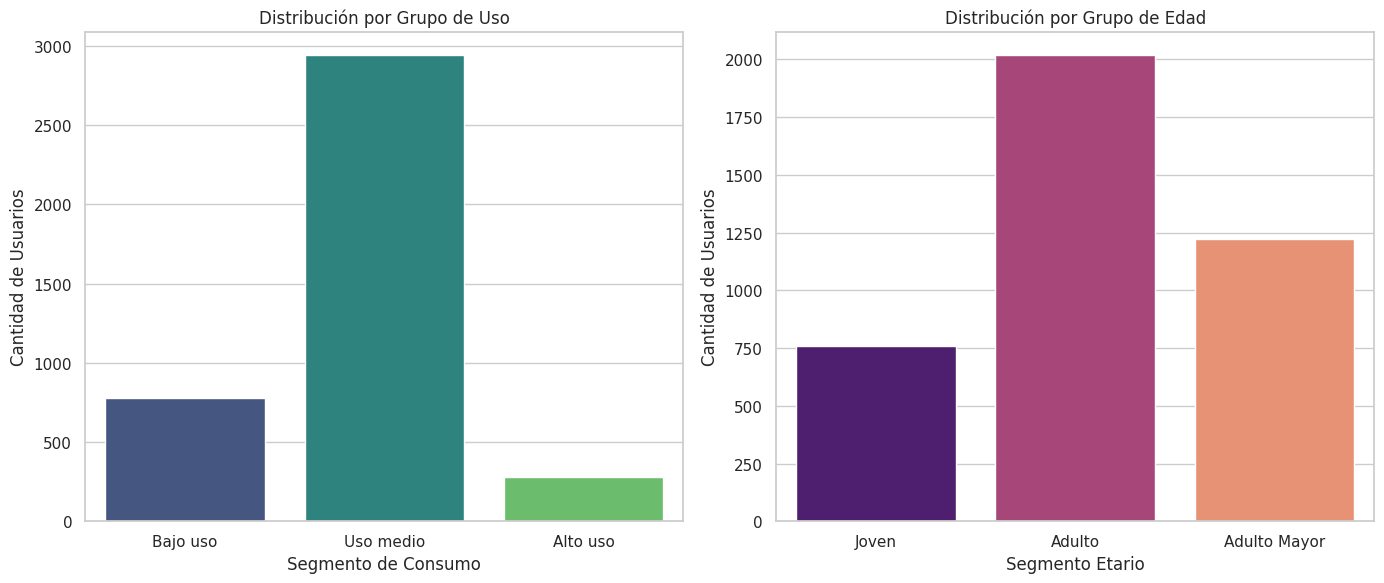

In [45]:
# Visualización de los segmentos por uso
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 1. Gráfico para Grupo de Uso
plt.subplot(1, 2, 1)
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='viridis')
plt.title('Distribución por Grupo de Uso')
plt.xlabel('Segmento de Consumo')
plt.ylabel('Cantidad de Usuarios')

# 2. Gráfico para Grupo de Edad
plt.subplot(1, 2, 2)
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='magma')
plt.title('Distribución por Grupo de Edad')
plt.xlabel('Segmento Etario')
plt.ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()

---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ Problemas detectados en los datos

El dataset original presentaba problemas críticos de integridad que habrían sesgado cualquier decisión comercial:
    Fechas Imposibles: Se detectaron 40 registros (1%) con año de registro 2026 y 50 valores nulos en la tabla de uso. Se corrigieron para evitar cálculos de antigüedad negativos.
    Valores Sentinel: En la columna de edad, encontramos el valor -999 que distorsionaba el promedio.
    Datos Faltantes (MNAR): Se identificó que el 55% de los datos de duration eran nulos, pero no por error, sino porque el sistema no mide tiempo en mensajes de texto. Se segmentó el análisis para evitar errores de cálculo.
    Outliers: Se hallaron valores extremos en duración de llamadas (hasta 185 min), representando un comportamiento de "Power User" real y no un error técnico.

🔍 Segmentos por Edad

La base de clientes tiene una estructura de "campana de Gauss" (distribución simétrica):
    Adultos (30-59 años): Es el segmento mayoritario. Muestran un equilibrio entre consumo de datos y voz, siendo el grupo con mayor estabilidad en el Plan Premium.
    Jóvenes (< 30 años): Segmento con tendencia a la mensajería instantánea.
    Adulto Mayor (60+ años): Representan el grupo con mayor lealtad y preferencia por el canal de voz tradicional.

📊 Segmentos por Nivel de Uso

Clasificamos a los usuarios según su intensidad de interacción:
    Bajo Uso: Usuarios con < 5 llamadas y mensajes. Representan una oportunidad de activación.
    Uso Medio: El "corazón" de ConnectaTel. Usuarios que utilizan entre 5 y 9 eventos.
    Alto Uso: Clientes que alcanzan el límite de 10 interacciones. Son los usuarios más activos pero, debido al límite del dataset, podrían estar subestimados en su valor real.

➡️ Esto sugiere que...

Existe una correlación directa entre el Plan Premium y la duración de las llamadas, pero no necesariamente con la cantidad de mensajes. Los usuarios no pagan por "hacer más cosas", sino por "hacerlas durante más tiempo". El hecho de que ningún usuario supere los 10 registros sugiere que tenemos un límite en la captura de datos que podría estar ocultando a nuestros clientes más valiosos (clase AAA).

💡 Recomendaciones
    Plan "Voz Infinita" para Adultos Mayores: Dado que este segmento prefiere las llamadas largas (outliers de minutos), un plan especializado en minutos ilimitados tendría una alta tasa de conversión aquí.
    Paquetes de Mensajería para Jóvenes: Los usuarios jóvenes no valoran tanto la duración de la llamada. Se recomienda un plan "Social-Only" con enfoque en mensajes y datos.
    Campaña de Upselling para "Alto Uso - Básico": Identificamos usuarios en el Plan Básico que ya alcanzan los topes de uso. Estos son candidatos inmediatos para migrar al Plan Premium mediante una oferta personalizada.
    Optimización de Captura de Datos: Eliminar el límite de 10 registros por usuario en los sistemas de registro para poder identificar el techo real de consumo de los Power Users.